# Analyze which class has changed to which one

In [1]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings

In [2]:
# Suppress warnings
warnings.filterwarnings("ignore")

In [3]:
# Paths to datasets
path_2019 = "./classified_maps/VNP_landcover_2019.tif"
path_2024a = "./classified_maps/VNP_landcover_2024.tif"
path_2024b = "./predicted_results/vnp_lc_2024_ann.tif"
path_2029 = "./predicted_results/vnp_lc_2029_ann.tif"
path_2034 = "./predicted_results/vnp_lc_2034_ann.tif"
path_2039 = "./predicted_results/vnp_lc_2039_ann.tif"
path_2044 = "./predicted_results/vnp_lc_2044_ann.tif"
path_2049 = "./predicted_results/vnp_lc_2049_ann.tif"

In [4]:
def load_image(file_path, load_all_bands=False):
    try:
        with rasterio.open(file_path) as src:
            if load_all_bands:
                raster_data = src.read() 
            else:
                raster_data = src.read(1) 

            metadata = src.meta
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

            return raster_data, metadata, extent

    except Exception as e:
        print(f"Error loading raster file: {file_path}")
        raise e

In [5]:
landcover_2019, meta_2019, extent_2019 = load_image(path_2019)
landcover_2024a, meta_2024, extent_2024 = load_image(path_2024a)
landcover_2024b, meta_2024, extent_2024 = load_image(path_2024b)
landcover_2029, meta_2029, extent_2029 = load_image(path_2029)
landcover_2034, meta_2034, extent_2034 = load_image(path_2034)
landcover_2039, meta_2039, extent_2039 = load_image(path_2039)
landcover_2044, meta_2044, extent_2044 = load_image(path_2044)
landcover_2049, meta_2049, extent_2049 = load_image(path_2049)

### Converts a raster into a GeoDataFrame with land cover classes as polygons 

In [6]:
def polygonize_raster(image, transform, crs, nodata_value=0):
    # Ensure the input is a NumPy array
    if not isinstance(image, np.ndarray):
        raise TypeError("Expected a NumPy array for 'image'")

    # Create a mask to exclude NoData values
    mask = image != nodata_value

    # Polygonize the raster
    polygons = [
        (shape(geom), value)
        for geom, value in shapes(image, mask=mask, transform=transform)
    ]

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        {"geometry": [geom for geom, _ in polygons], 
         "class": [value for _, value in polygons]},
        crs=crs
    )

    return gdf

In [7]:
gdf_2019 = polygonize_raster(landcover_2019, meta_2019["transform"], meta_2019["crs"])
gdf_2024a = polygonize_raster(landcover_2024a, meta_2024["transform"], meta_2024["crs"])
gdf_2024b = polygonize_raster(landcover_2024b, meta_2024["transform"], meta_2024["crs"])
gdf_2029 = polygonize_raster(landcover_2029, meta_2029["transform"], meta_2029["crs"])
gdf_2034 = polygonize_raster(landcover_2034, meta_2034["transform"], meta_2034["crs"])
gdf_2039 = polygonize_raster(landcover_2039, meta_2039["transform"], meta_2039["crs"])
gdf_2044 = polygonize_raster(landcover_2044, meta_2044["transform"], meta_2044["crs"])
gdf_2049 = polygonize_raster(landcover_2049, meta_2049["transform"], meta_2049["crs"])

In [8]:
gdf_2019.head()

,geometry,class
0,"POLYGON ((801030 9850320, 801030 9850310, 8010...",1.0
1,"POLYGON ((800990 9850290, 800990 9850280, 8010...",1.0
2,"POLYGON ((800920 9850240, 800920 9850230, 8009...",1.0
3,"POLYGON ((800720 9850230, 800720 9850220, 8007...",4.0
4,"POLYGON ((800930 9850230, 800930 9850220, 8009...",1.0


### Add or classify classes "with real class names" 

In [9]:
def classify_lc(gdf, code_column="class"):
    if not isinstance(gdf, gpd.GeoDataFrame):
        raise TypeError("Expected a GeoDataFrame.")

    # Mapping of land cover codes to their corresponding class names
    class_names = {
        1: "Bamboo",
        2: "Mixed forest",
        3: "Hagenia-Hypericum",
        4: "Herbaceous",
        5: "Subalpine",
        6: "Alpine",
        7: "Water",
        8: "Bare",
        9: "Meadow"
    }

    # Ensure the code column is numeric
    gdf[code_column] = pd.to_numeric(gdf[code_column], errors="coerce")

    # Assign class names based on the numeric class column
    gdf["class_name"] = gdf[code_column].map(class_names).fillna("Unknown")

    # Calculate area for each polygon in km²
    gdf["area_km2"] = gdf.geometry.area / 10**6  # Convert m² to km²

    # Dissolve features with the same 'class_name' and compute the total area for each class
    dissolved_gdf = gdf.dissolve(by="class_name", aggfunc="sum", as_index=False)

    return dissolved_gdf

In [10]:
gdf_2019 = classify_lc(gdf_2019)
gdf_2024a = classify_lc(gdf_2024a)
gdf_2024b = classify_lc(gdf_2024b)
gdf_2029 = classify_lc(gdf_2029)
gdf_2034 = classify_lc(gdf_2034)
gdf_2039 = classify_lc(gdf_2039)
gdf_2044 = classify_lc(gdf_2044)
gdf_2049 = classify_lc(gdf_2049)

In [11]:
gdf_2019.head()

,class_name,geometry,class,area_km2
0,Alpine,"MULTIPOLYGON (((770130 9829680, 770130 9829670...",6066.0,14.6020
1,Bamboo,"MULTIPOLYGON (((767630 9829310, 767620 9829310...",1554.0,48.6548
2,Bare,"MULTIPOLYGON (((767310 9829520, 767300 9829520...",2344.0,1.1432
3,Hagenia-Hypericum,"MULTIPOLYGON (((768520 9829560, 768520 9829590...",6681.0,46.9118
4,Herbaceous,"MULTIPOLYGON (((767660 9829610, 767640 9829610...",6340.0,6.8108


### Change detection 

In [12]:
def detect_lc_change(gdf1, gdf2, year1, year2):
    # Ensure the DataFrames have the necessary columns
    required_cols = ['class_name', 'geometry']
    for col in required_cols:
        if col not in gdf1.columns or col not in gdf2.columns:
            raise ValueError(f"Missing required column: {col}")
    
    # Perform spatial intersection to detect changes
    intersection = gpd.overlay(gdf1, gdf2, how='intersection')
    
    # Add columns to track changes
    intersection[f'class_name_{year1}'] = intersection['class_name_1']
    intersection[f'class_name_{year2}'] = intersection['class_name_2']
    
    # Identify where class has changed
    intersection['class_changed'] = intersection[f'class_name_{year1}'] != intersection[f'class_name_{year2}']
    
    # Create detailed change column
    def create_change_description(row):
        if row['class_changed']:
            return f"{row[f'class_name_{year1}']} to {row[f'class_name_{year2}']}"
        return "No change"
    
    intersection['change_description'] = intersection.apply(create_change_description, axis=1)
    
    # Calculate area of changes
    intersection['change_area_km2'] = intersection.geometry.area / 10**6  # Convert to km²
    
    # Select and reorder columns for clarity
    output_columns = [
        'class_changed', 
        f'class_name_{year1}', 
        f'class_name_{year2}', 
        'change_description', 
        'change_area_km2', 
        'geometry'
    ]
    
    return intersection[output_columns]

In [13]:
lc_change_2019_2024a = detect_lc_change(gdf_2019, gdf_2024a, 2019, 2024)
lc_change_2024b_2029 = detect_lc_change(gdf_2024b, gdf_2029, 2024, 2029)
lc_change_2029_2034 = detect_lc_change(gdf_2029, gdf_2034, 2029, 2034)
lc_change_2034_2039 = detect_lc_change(gdf_2034, gdf_2039, 2034, 2039)
lc_change_2039_2044 = detect_lc_change(gdf_2039, gdf_2044, 2039, 2044)
lc_change_2044_2049 = detect_lc_change(gdf_2044, gdf_2049, 2044, 2049)
lc_change_2024b_2049 = detect_lc_change(gdf_2024b, gdf_2049, 2024, 2049)
lc_change_2019_2049 = detect_lc_change(gdf_2019, gdf_2049, 2019, 2049)

In [14]:
lc_change_2019_2049.head()

,class_changed,class_name_2019,class_name_2049,change_description,change_area_km2,geometry
0,False,Alpine,Alpine,No change,12.9973,"MULTIPOLYGON (((771620 9830550, 771620 9830560..."
1,True,Alpine,Bamboo,Alpine to Bamboo,0.0087,"MULTIPOLYGON (((778350 9830270, 778360 9830270..."
2,True,Alpine,Bare,Alpine to Bare,0.2728,"MULTIPOLYGON (((772560 9831200, 772570 9831200..."
3,True,Alpine,Hagenia-Hypericum,Alpine to Hagenia-Hypericum,0.1435,"MULTIPOLYGON (((770130 9829670, 770120 9829670..."
4,True,Alpine,Herbaceous,Alpine to Herbaceous,0.0043,"MULTIPOLYGON (((777960 9829760, 777940 9829760..."


In [15]:
# Calculate a new area field [area_km2]
lc_change_2019_2024a['area_km2'] = lc_change_2019_2024a.geometry.area / 1e6
lc_change_2024b_2029['area_km2'] = lc_change_2024b_2029.geometry.area / 1e6
lc_change_2029_2034['area_km2'] = lc_change_2029_2034.geometry.area / 1e6
lc_change_2034_2039['area_km2'] = lc_change_2034_2039.geometry.area / 1e6
lc_change_2039_2044['area_km2'] = lc_change_2039_2044.geometry.area / 1e6
lc_change_2044_2049['area_km2'] = lc_change_2044_2049.geometry.area / 1e6
lc_change_2024b_2049['area_km2'] = lc_change_2024b_2049.geometry.area / 1e6
lc_change_2019_2049['area_km2'] = lc_change_2019_2049.geometry.area / 1e6

In [16]:
lc_change_2019_2024a['area_km2'] = lc_change_2019_2024a['area_km2'].round(3)
lc_change_2024b_2029['area_km2'] = lc_change_2024b_2029['area_km2'].round(3)
lc_change_2029_2034['area_km2'] = lc_change_2029_2034['area_km2'].round(3)
lc_change_2034_2039['area_km2'] = lc_change_2034_2039['area_km2'].round(3)
lc_change_2039_2044['area_km2'] = lc_change_2039_2044['area_km2'].round(3)
lc_change_2044_2049['area_km2'] = lc_change_2044_2049['area_km2'].round(3)
lc_change_2024b_2049['area_km2'] = lc_change_2024b_2049['area_km2'].round(3)
lc_change_2019_2049['area_km2'] = lc_change_2019_2049['area_km2'].round(3)

In [17]:
# Pivot the data to create a confusion matrix-like structure
pivot_2019_2049 = lc_change_2019_2049.pivot_table(index='class_name_2019', columns='class_name_2049', values='area_km2', aggfunc='sum', fill_value=0)
pivot_2019_2024a = lc_change_2019_2024a.pivot_table(index='class_name_2019', columns='class_name_2024', values='area_km2', aggfunc='sum', fill_value=0)
pivot_2024b_2049 = lc_change_2024b_2049.pivot_table(index='class_name_2024', columns='class_name_2049', values='area_km2', aggfunc='sum', fill_value=0)
pivot_2024_2029 = lc_change_2024b_2029.pivot_table(index='class_name_2024', columns='class_name_2029', values='area_km2', aggfunc='sum', fill_value=0)
pivot_2029_2034 = lc_change_2029_2034.pivot_table(index='class_name_2029', columns='class_name_2034', values='area_km2', aggfunc='sum', fill_value=0)
pivot_2034_2039 = lc_change_2034_2039.pivot_table(index='class_name_2034', columns='class_name_2039', values='area_km2', aggfunc='sum', fill_value=0)
pivot_2039_2044 = lc_change_2039_2044.pivot_table(index='class_name_2039', columns='class_name_2044', values='area_km2', aggfunc='sum', fill_value=0)
pivot_2044_2049 = lc_change_2044_2049.pivot_table(index='class_name_2044', columns='class_name_2049', values='area_km2', aggfunc='sum', fill_value=0)

In [18]:
pivot_2024b_2049

class_name_2049,Alpine,Bamboo,Bare,Hagenia-Hypericum,Herbaceous,Meadow,Mixed forest,Subalpine,Water
class_name_2024,,,,,,,,,
Alpine,13.390,0.000,0.197,0.064,0.000,0.000,0.000,0.768,0.000
Bamboo,0.000,42.906,0.008,0.400,3.550,0.894,0.139,0.100,0.000
Bare,0.011,0.006,1.022,0.052,0.000,0.029,0.000,0.075,0.000
Hagenia-Hypericum,0.008,0.887,0.122,43.719,2.428,0.034,0.002,0.241,0.000
Herbaceous,0.000,2.113,0.000,0.127,6.197,0.090,0.021,0.112,0.000
Meadow,0.000,0.057,0.025,0.000,0.000,3.299,0.002,0.000,0.000
Mixed forest,0.000,0.946,0.002,0.009,0.400,0.266,4.876,0.002,0.000
Subalpine,0.306,0.404,0.097,2.774,0.165,0.578,0.000,26.610,0.000
Water,0.008,0.000,0.088,0.000,0.000,0.000,0.000,0.009,0.008


### Change between 2019 and 2024 

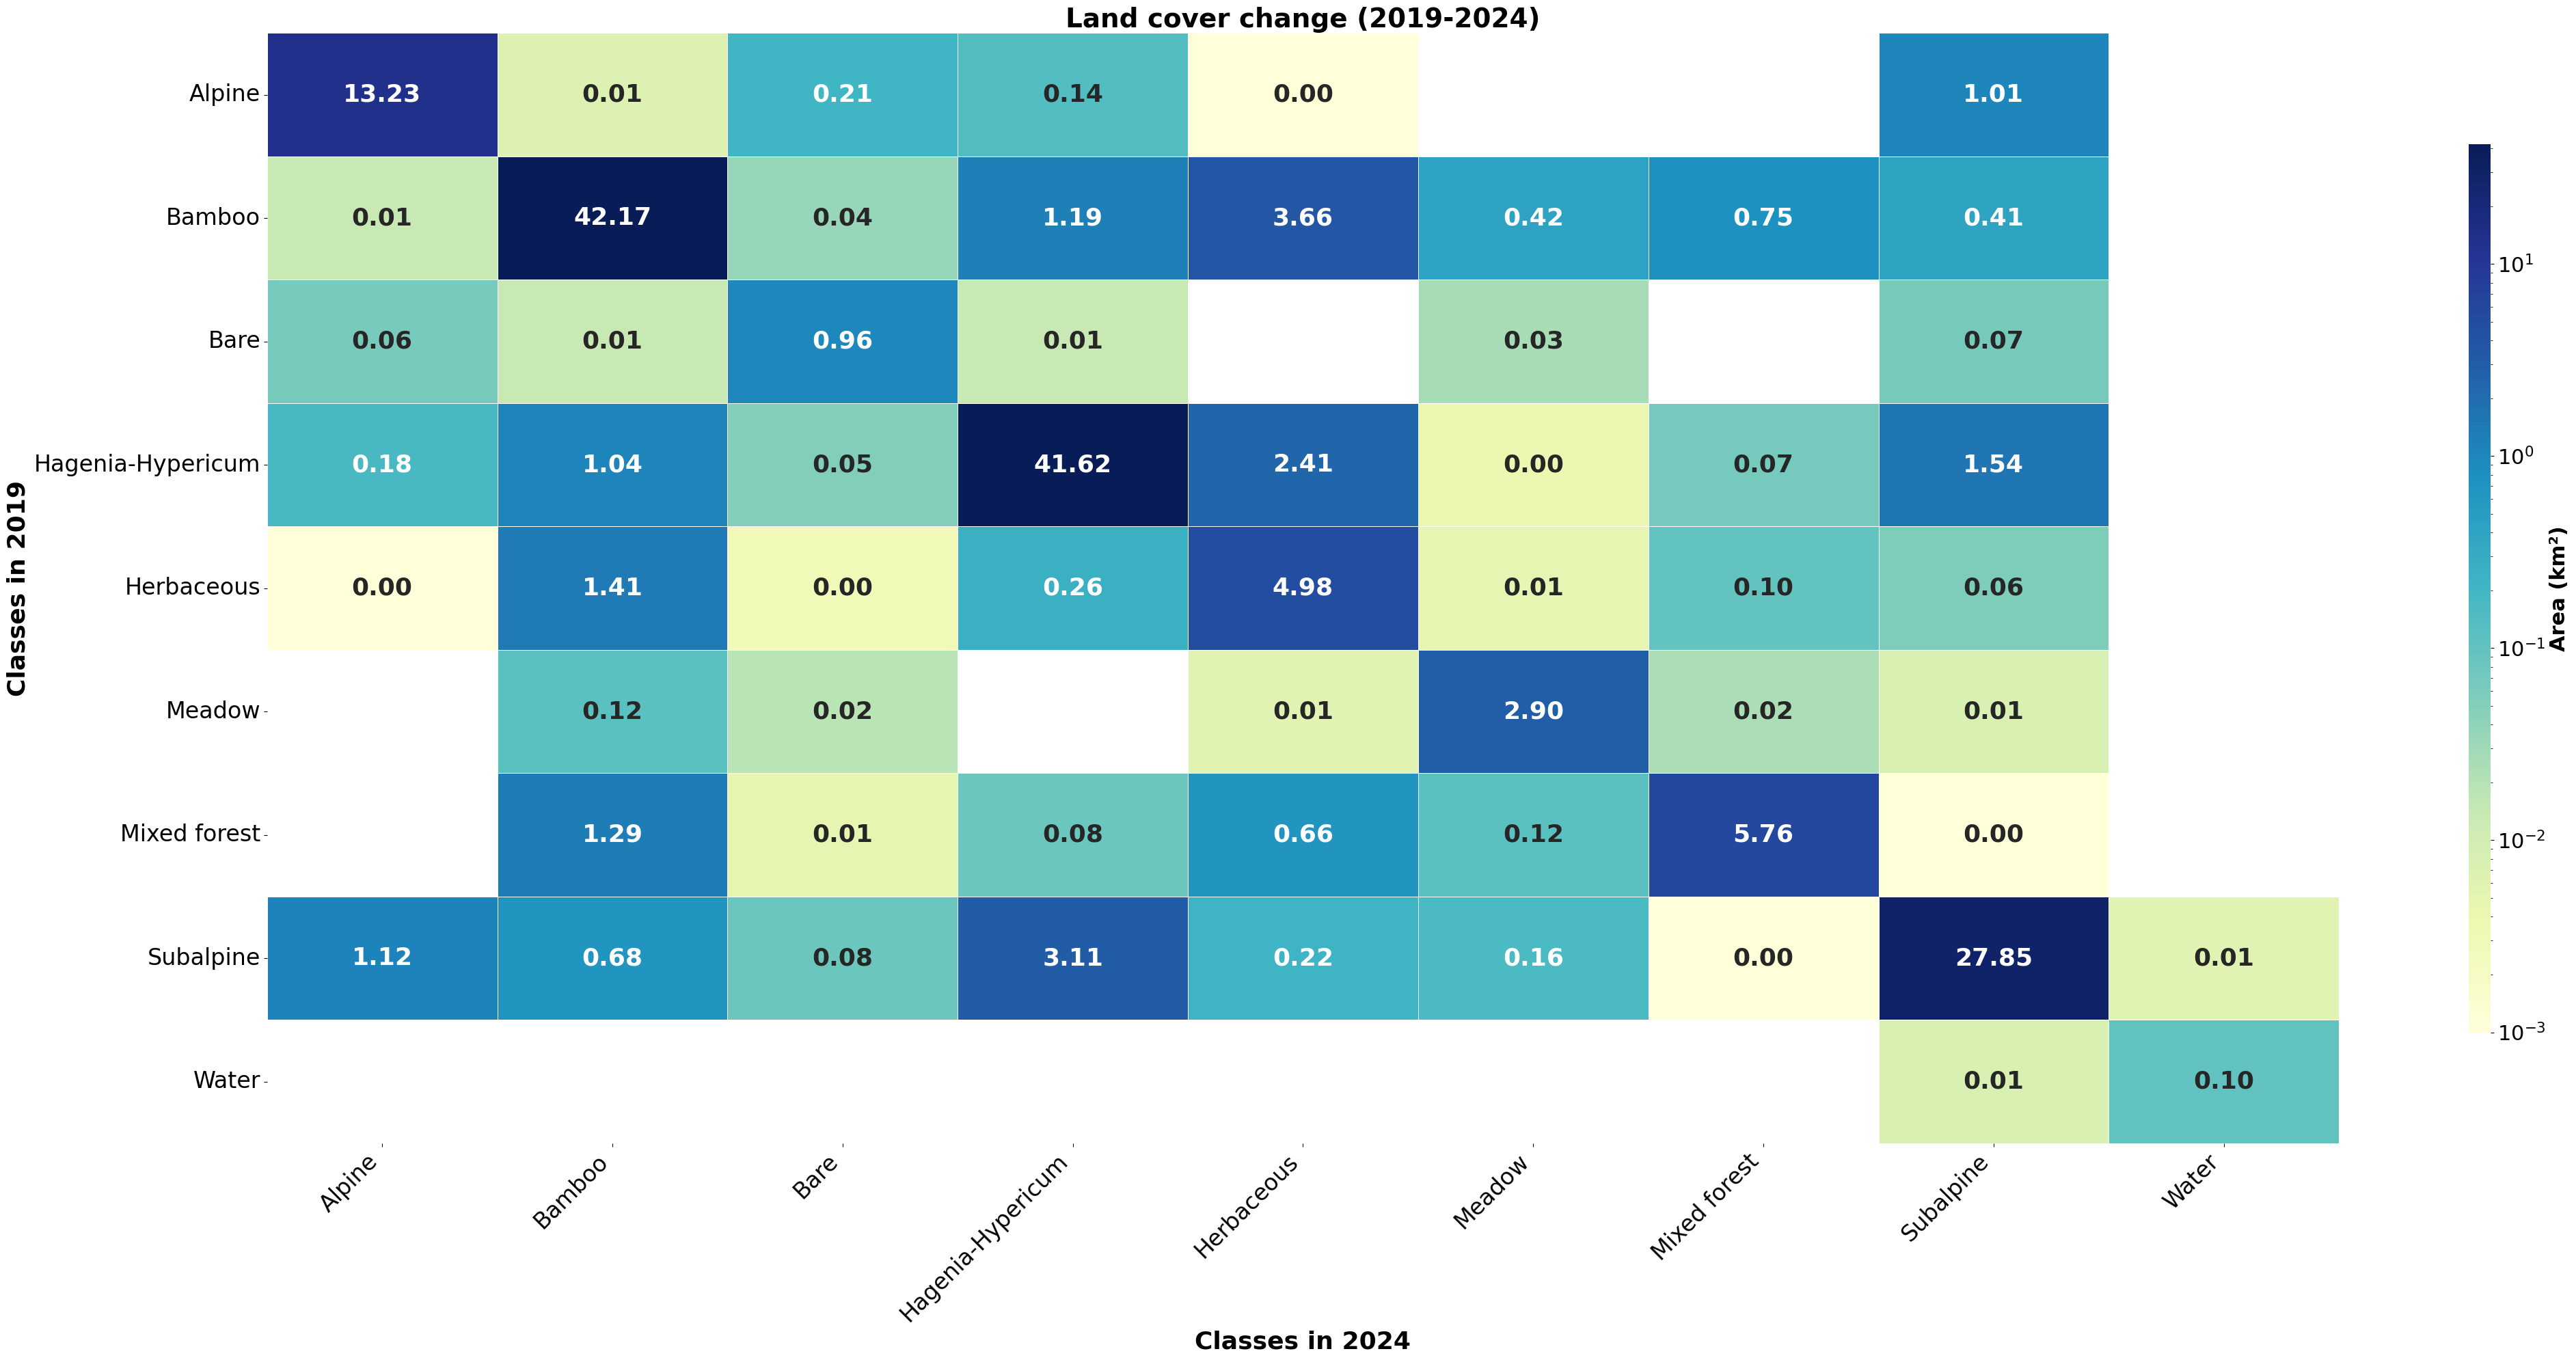

In [19]:
# Ensure the pivot table is a NumPy array
data = pivot_2019_2024a.to_numpy()

# Mask to hide zero values for better visibility
mask = data == 0

# Define min/max for log scale, ignoring zero values
non_zero_values = data[data > 0]  # Extract non-zero values
vmin = non_zero_values.min() if len(non_zero_values) > 0 else 1  # Avoid errors
vmax = data.max()

# Create a logarithmic normalization for the color scale
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

plt.figure(figsize=(42, 20))

# Create the heatmap 
heatmap = sns.heatmap(
    pivot_2019_2024a,  
    annot=True, 
    fmt='.2f', 
    cmap='YlGnBu', 
    linewidths=0.5, 
    mask=mask, 
    norm=norm,  
    cbar_kws={
        'label': 'Area (km²)',
        'shrink': 0.8,
        'aspect': 40,  
        'pad': 0.05,  
        'orientation': 'vertical'
    },
    annot_kws={"size": 26, "weight": 'bold'}
)

# Customize the colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=22) 
cbar.set_label('Area (km²)', fontsize=22, fontweight='bold') 

# Improve other elements
plt.xlabel('Classes in 2024', fontsize=26, fontweight='bold')
plt.ylabel('Classes in 2019', fontsize=26, fontweight='bold')
plt.title('Land cover change (2019-2024)', fontsize=28, fontweight='bold')

# Rotate axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=24)
plt.yticks(rotation=0, fontsize=24)

# Adjust layout to prevent clipping
plt.tight_layout()

plt.savefig("./refined_land_cover_vnp_change_2019-2024.jpg", format='jpeg', dpi=300, bbox_inches='tight')

plt.show()

### General change between 2019 and 2049 

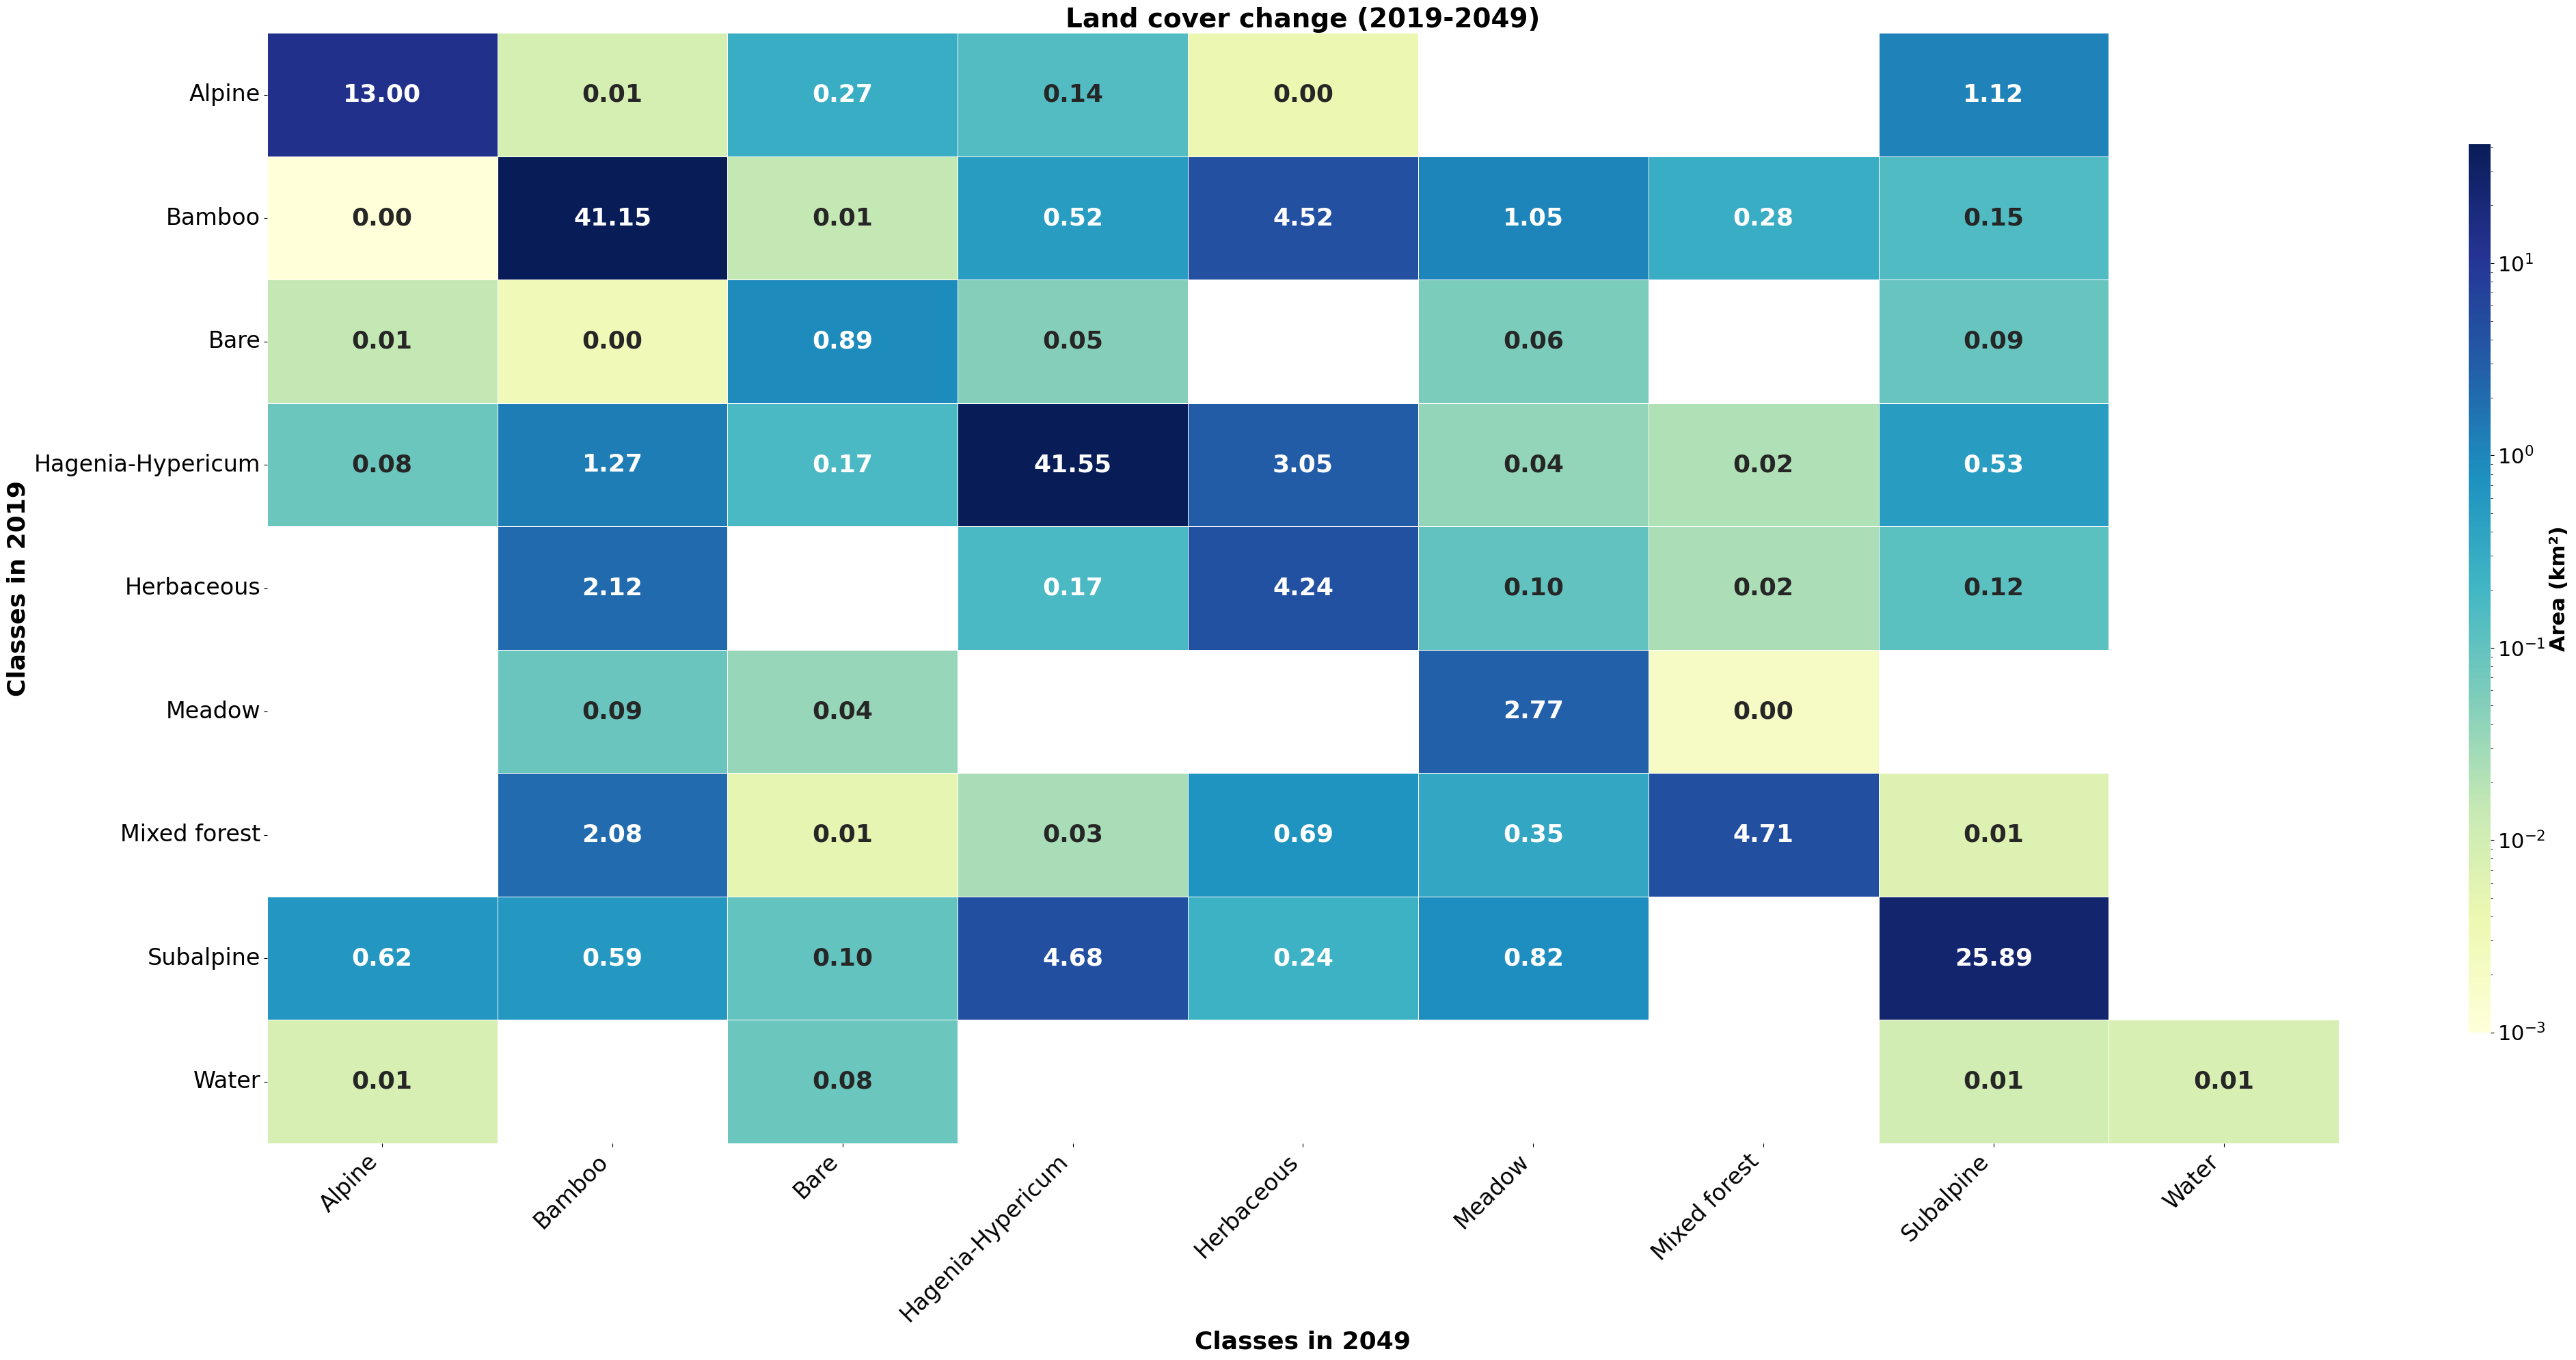

In [20]:
# Ensure the pivot table is a NumPy array
data = pivot_2019_2049.to_numpy()

# Mask to hide zero values for better visibility
mask = data == 0

# Define min/max for log scale, ignoring zero values
non_zero_values = data[data > 0]  # Extract non-zero values
vmin = non_zero_values.min() if len(non_zero_values) > 0 else 1  # Avoid errors
vmax = data.max()

# Create a logarithmic normalization for the color scale
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

plt.figure(figsize=(42, 20))

# Create the heatmap 
heatmap = sns.heatmap(
    pivot_2019_2049,  
    annot=True, 
    fmt='.2f', 
    cmap='YlGnBu', 
    linewidths=0.5, 
    mask=mask, 
    norm=norm,  
    cbar_kws={
        'label': 'Area (km²)',
        'shrink': 0.8,
        'aspect': 40,  
        'pad': 0.05,  
        'orientation': 'vertical'
    },
    annot_kws={"size": 26, "weight": 'bold'}
)

# Customize the colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=22) 
cbar.set_label('Area (km²)', fontsize=22, fontweight='bold') 

# Improve other elements
plt.xlabel('Classes in 2049', fontsize=26, fontweight='bold')
plt.ylabel('Classes in 2019', fontsize=26, fontweight='bold')
plt.title('Land cover change (2019-2049)', fontsize=28, fontweight='bold')

# Rotate axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=24)
plt.yticks(rotation=0, fontsize=24)

# Adjust layout to prevent clipping
plt.tight_layout()

plt.savefig("./refined_land_cover_vnp_change_2019-2049.jpg", format='jpeg', dpi=300, bbox_inches='tight')

plt.show()

### Plotting the change between predicted 2024 and predicted 2049 

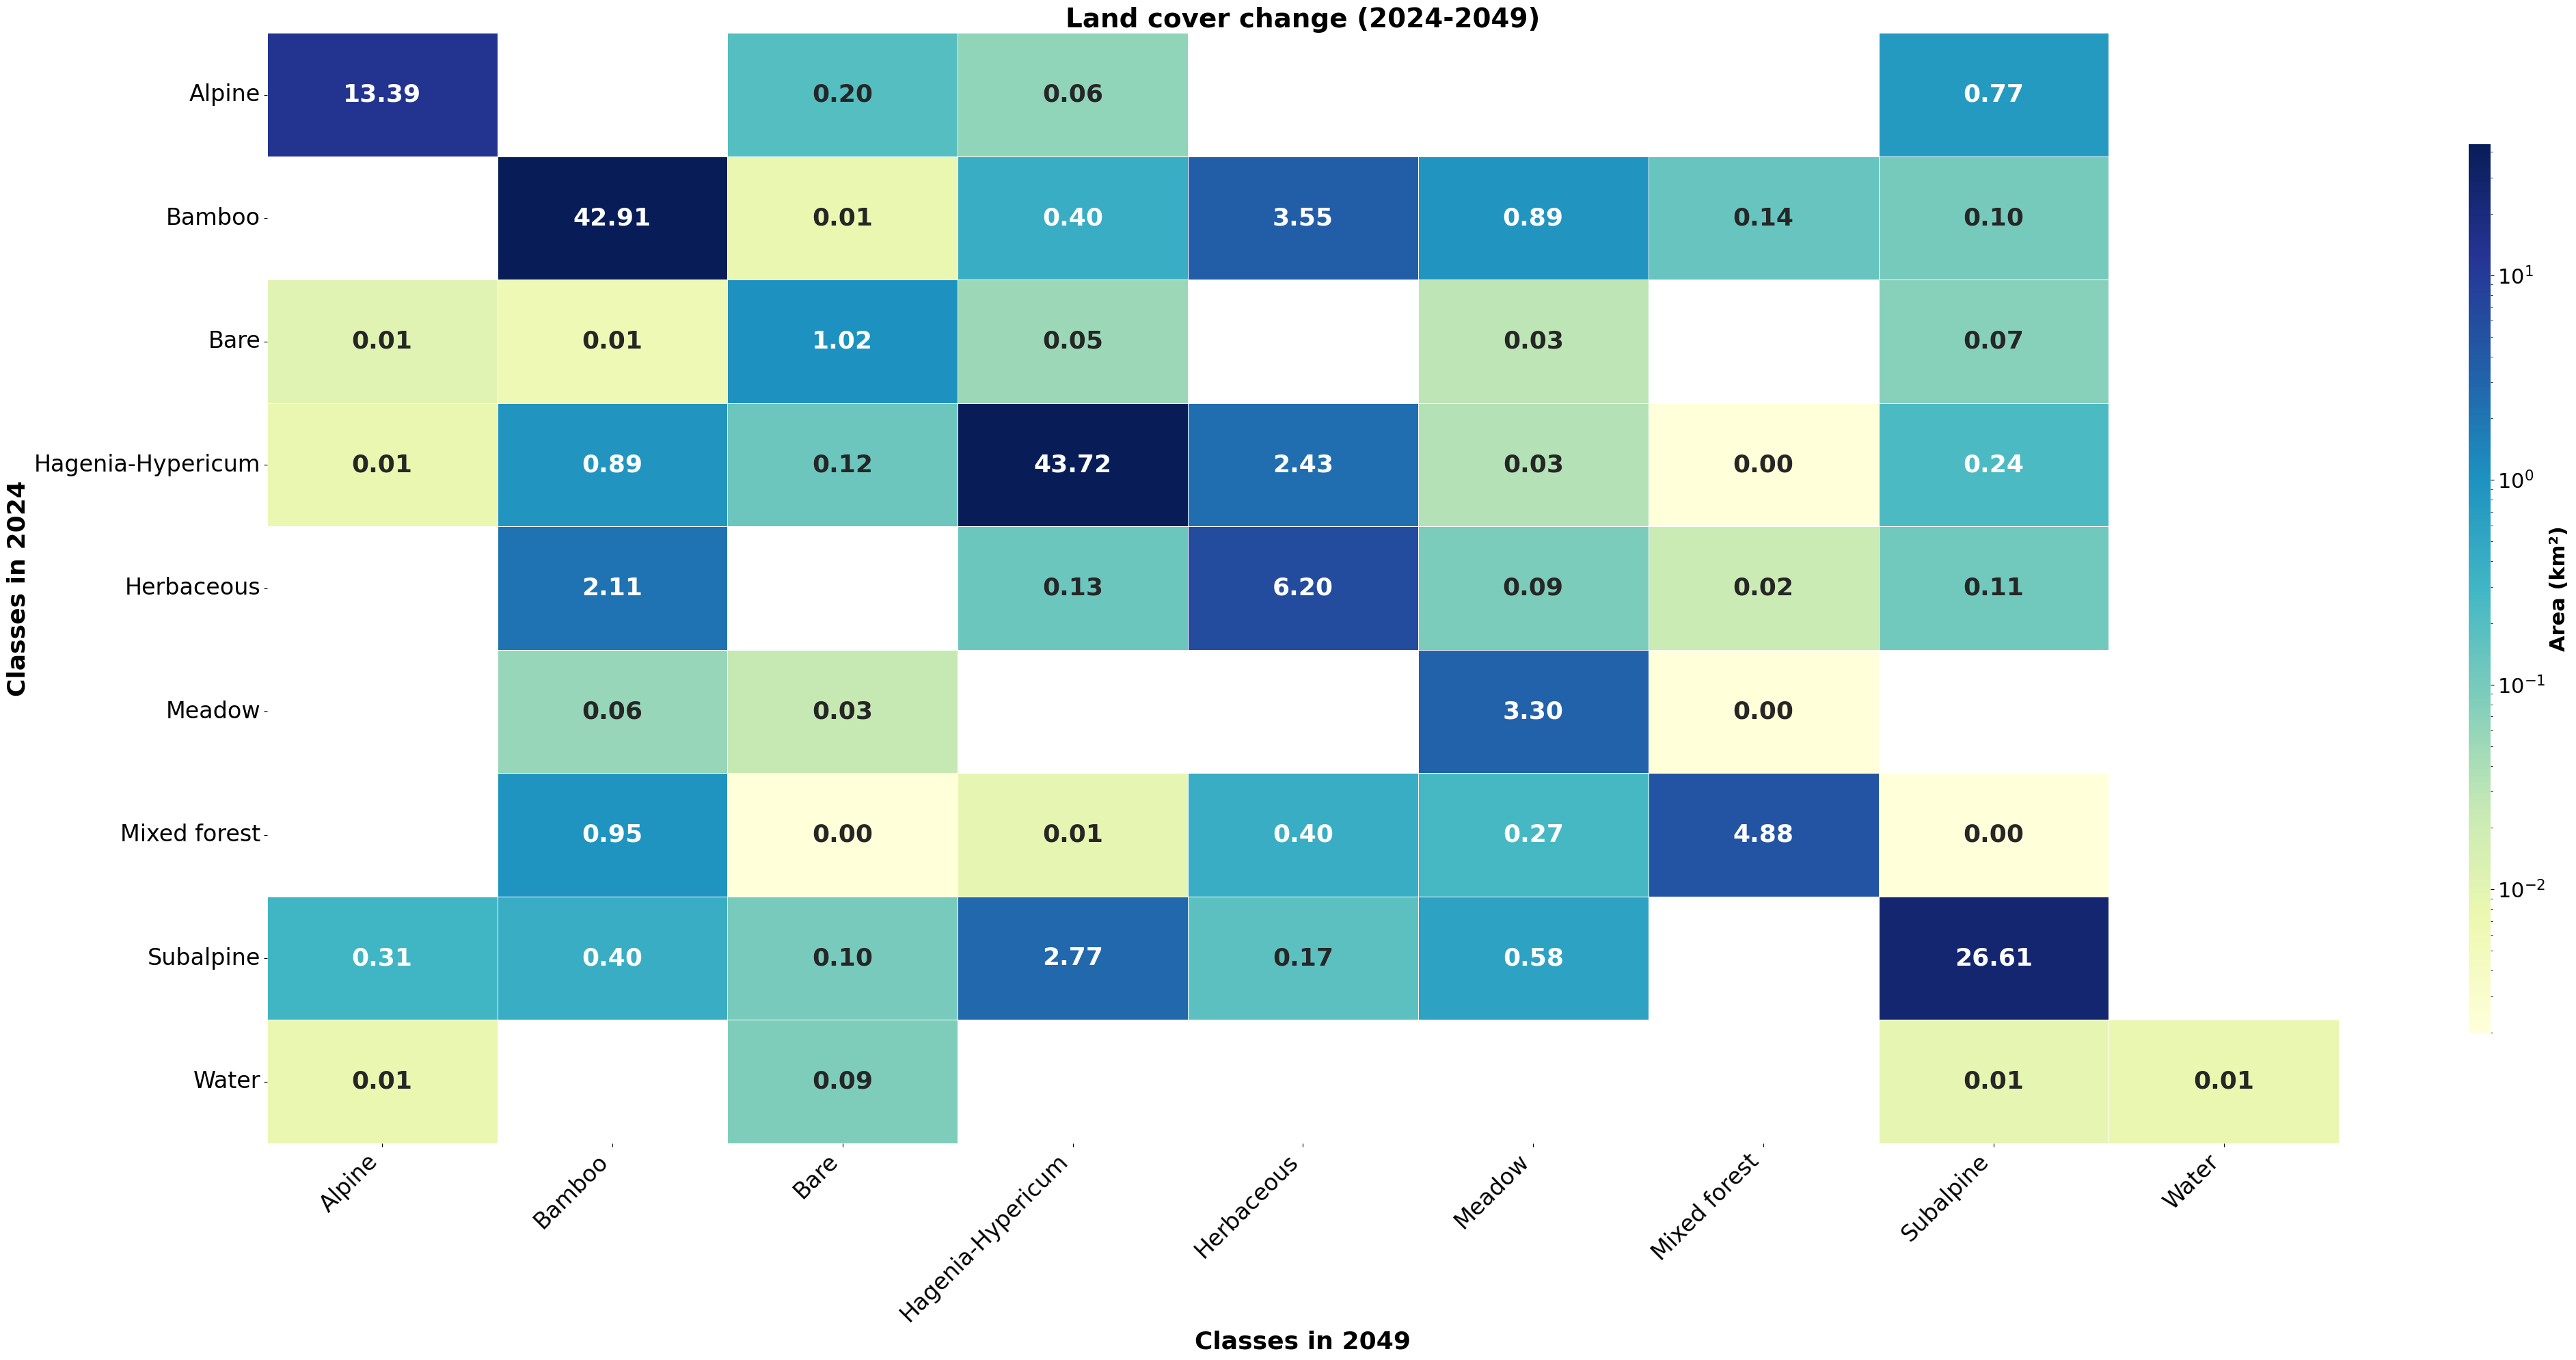

In [21]:
# Ensure the pivot table is a NumPy array
data = pivot_2024b_2049.to_numpy()

# Mask to hide zero values for better visibility
mask = data == 0

# Define min/max for log scale, ignoring zero values
non_zero_values = data[data > 0]  # Extract non-zero values
vmin = non_zero_values.min() if len(non_zero_values) > 0 else 1  # Avoid errors
vmax = data.max()

# Create a logarithmic normalization for the color scale
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

plt.figure(figsize=(42, 20))

# Create the heatmap 
heatmap = sns.heatmap(
    pivot_2024b_2049,  
    annot=True, 
    fmt='.2f', 
    cmap='YlGnBu', 
    linewidths=0.5, 
    mask=mask, 
    norm=norm,  
    cbar_kws={
        'label': 'Area (km²)',
        'shrink': 0.8,
        'aspect': 40,  
        'pad': 0.05,  
        'orientation': 'vertical'
    },
    annot_kws={"size": 26, "weight": 'bold'}
)

# Customize the colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=22) 
cbar.set_label('Area (km²)', fontsize=22, fontweight='bold') 

# Improve other elements
plt.xlabel('Classes in 2049', fontsize=26, fontweight='bold')
plt.ylabel('Classes in 2024', fontsize=26, fontweight='bold')
plt.title('Land cover change (2024-2049)', fontsize=28, fontweight='bold')

# Rotate axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=24)
plt.yticks(rotation=0, fontsize=24)

# Adjust layout to prevent clipping
plt.tight_layout()

plt.savefig("./refined_land_cover_vnp_change_predicted_2024-2049.jpg", format='jpeg', dpi=300, bbox_inches='tight')

plt.show()

### Plotting the time series

In [22]:
years = [2019, 2024, 2029, 2034, 2039, 2044, 2049]
gdfs = [gdf_2019, gdf_2024b, gdf_2029, gdf_2034, gdf_2039, gdf_2044, gdf_2049]

In [23]:
# Combine data into a single DataFrame
records = []
for year, gdf in zip(years, gdfs):
    for _, row in gdf.iterrows():
        records.append({
            "Year": year,
            "Class": row["class_name"],
            "Area_km2": row["area_km2"]
        })

df = pd.DataFrame(records)

In [24]:
class_order = df.groupby("Class")["Area_km2"].sum().sort_values(ascending=False).index.tolist()

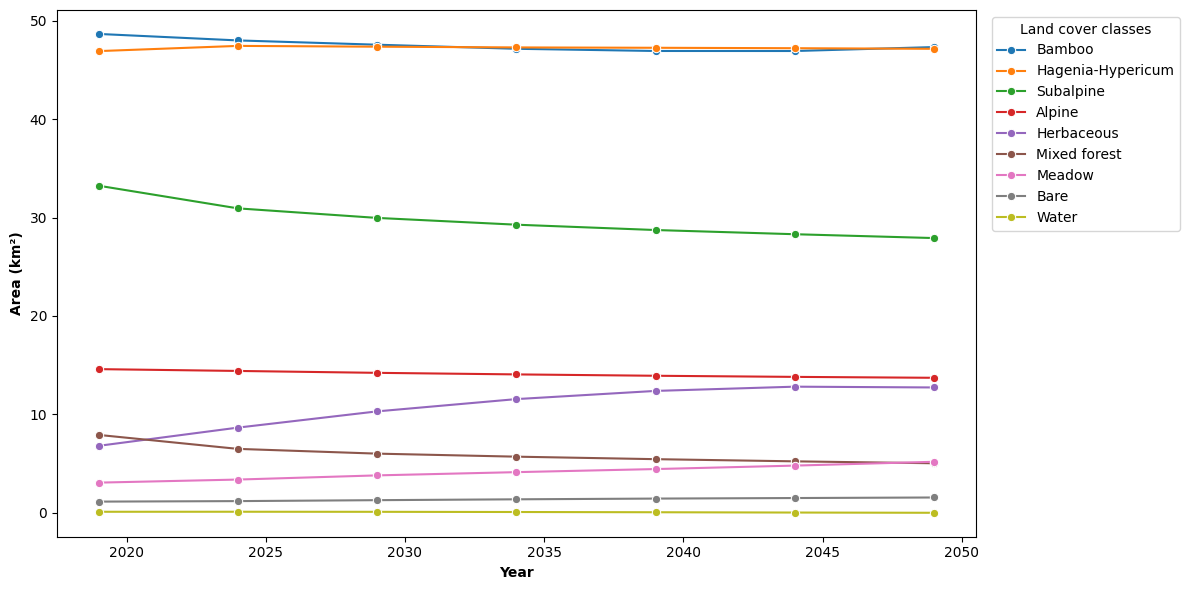

In [25]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Year", y="Area_km2", hue="Class", marker="o", palette="tab10", hue_order=class_order)

plt.title("")
plt.ylabel("Area (km²)", fontweight="bold")
plt.xlabel("Year", fontweight="bold")
plt.legend(title="Land cover classes", bbox_to_anchor=(1.01, 1), loc='upper left')
# plt.grid()
plt.tight_layout()
plt.savefig("./refined_timeseries_change_predicted_2019-2049.jpg", format='jpeg', dpi=300, bbox_inches='tight')

plt.show()

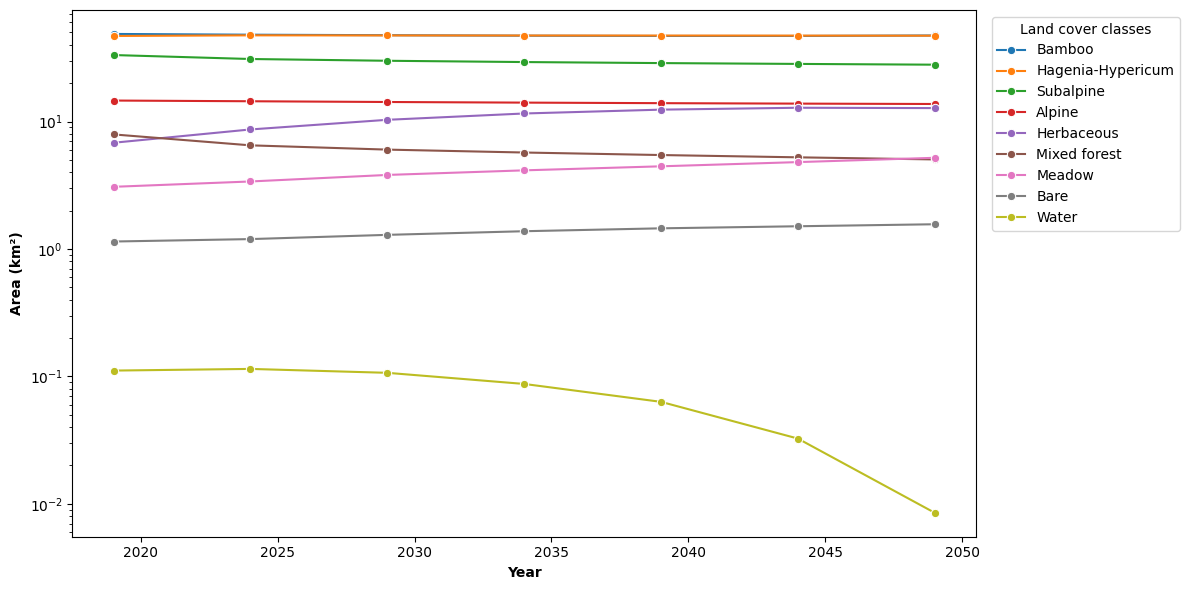

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Year", y="Area_km2", hue="Class", marker="o", palette="tab10", hue_order=class_order)

plt.title("")
plt.ylabel("Area (km²)", fontweight="bold")
plt.xlabel("Year", fontweight="bold")

plt.yscale("log")

plt.legend(title="Land cover classes", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig("./refined_timeseries_change_predicted_2019-2049.jpg", format='jpeg', dpi=300, bbox_inches='tight')
plt.show()